# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers**




**Members:** Nour NAJA |Alessandro CLERICI

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés, en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales des capteurs.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Chargement des données

In [3]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

# Suppression des capteurs dupliqués (N206 et N213 — coordonnées identiques, erreur de reporting)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Data exploration 1

In [4]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


## Merge sensors positions intro train data

In [5]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean Missing Values

In [6]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## 3. Data exploration 2

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


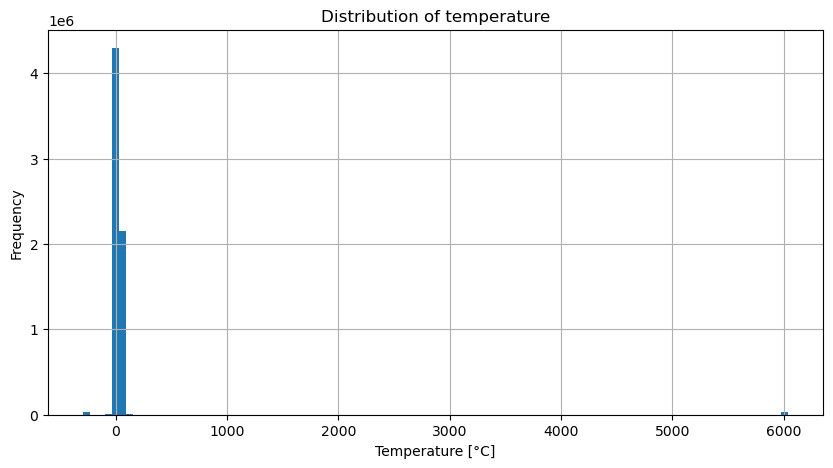

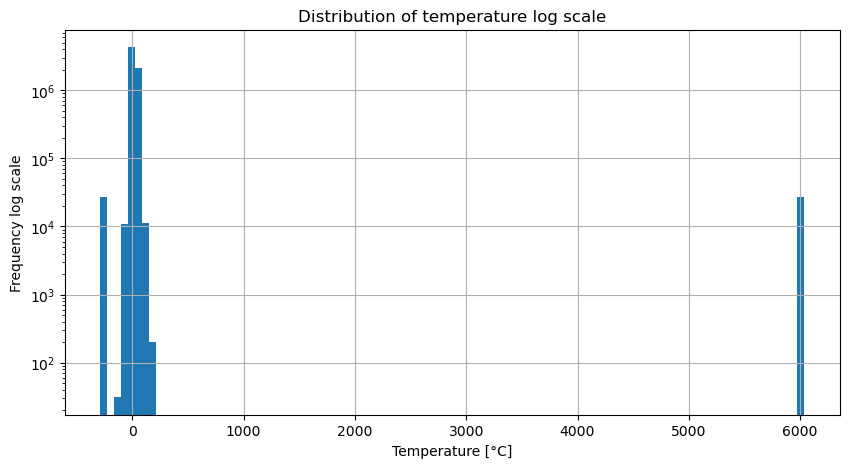

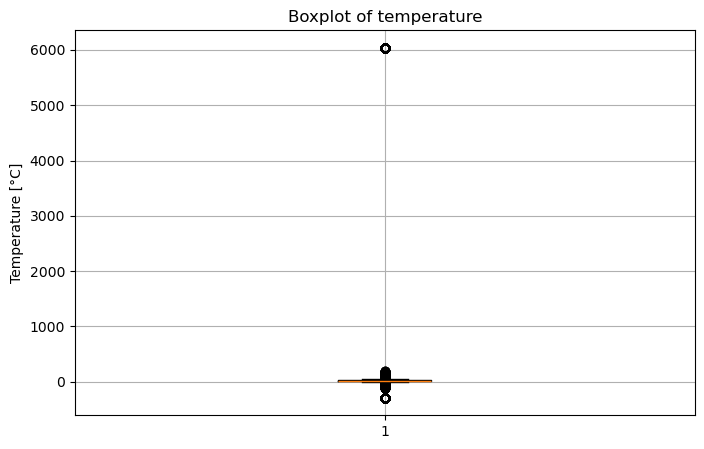

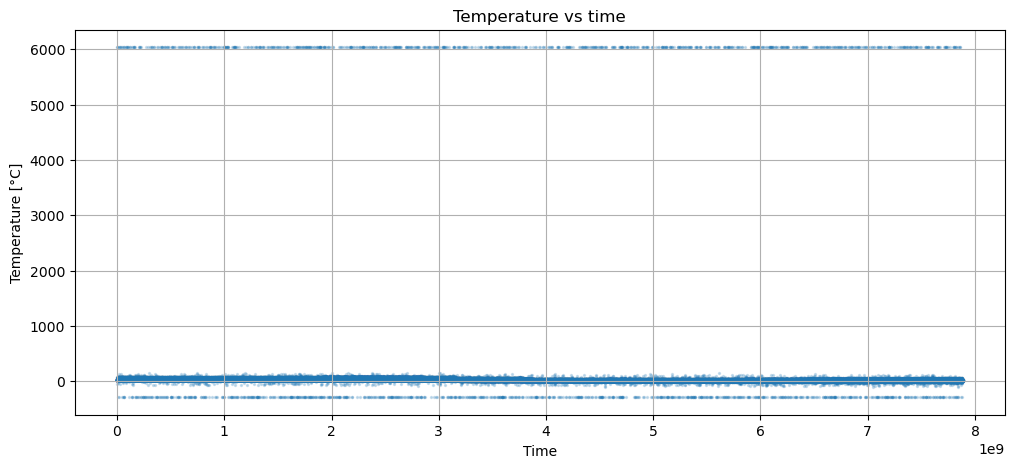

In [7]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

# Histogram (frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()

# Histogram (log frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()

# Temperature_Time
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

In [8]:
import plotly.graph_objects as go
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

fig = go.Figure()
fig.add_trace(go.Scatter(x=s_train['coor_x'], y=s_train['coor_y'],
    mode='markers', name='Train sensors',
    marker=dict(size=6, color='steelblue', opacity=0.6)))
fig.add_trace(go.Scatter(x=s_test['coor_x'], y=s_test['coor_y'],
    mode='markers', name='Test sensors',
    marker=dict(size=8, color='tomato', symbol='diamond', opacity=0.9)))
fig.update_layout(title='Positions des capteurs (2D)',
    xaxis_title='X', yaxis_title='Y', width=700, height=500)
fig.show()

print(f'Capteurs train dans buffer (x<=1.4) : {(s_train["coor_x"] <= 1.4).sum()}')
print(f'Capteurs test dans buffer (x<=1.4)  : {(s_test["coor_x"] <= 1.4).sum()}')

Capteurs train dans buffer (x<=1.4) : 56
Capteurs test dans buffer (x<=1.4)  : 18


## 4. Preprocessing 

### MAD : remove outliers

In [9]:
# ============================================================
# Identify global temperature outliers using MAD
# ============================================================

temp = train_full["temperature"]

median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))

robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full["temperature_robust_z"] = robust_z
train_full["is_global_outlier"] = train_full["temperature_robust_z"].abs() > 6

print("Global temperature median:", median_temp)
print("Global temperature MAD:", mad_temp)
print("Numero global outliers:", train_full["is_global_outlier"].sum())

display(
    train_full.loc[
        train_full["is_global_outlier"],
        ["sensor", "time", "temperature", "temperature_robust_z", "coor_x", "coor_y"]
    ].sort_values("temperature_robust_z", key=np.abs, ascending=False).head(30)
)

Global temperature median: 19.394394
Global temperature MAD: 6.2745953
Numero global outliers: 114636


,sensor,time,temperature,temperature_robust_z,coor_x,coor_y
4390568,N927,0.000000e+00,6039.049805,647.094727,1.182325,3.28376
4390569,N927,8.640000e+05,6039.049805,647.094727,1.182325,3.28376
4390570,N927,1.728000e+06,6039.049805,647.094727,1.182325,3.28376
4390571,N927,2.592000e+06,6039.049805,647.094727,1.182325,3.28376
4390572,N927,3.456000e+06,6039.049805,647.094727,1.182325,3.28376
4390573,N927,4.320000e+06,6039.049805,647.094727,1.182325,3.28376
4390574,N927,5.184000e+06,6039.049805,647.094727,1.182325,3.28376
4390575,N927,6.048000e+06,6039.049805,647.094727,1.182325,3.28376
4390576,N927,6.912000e+06,6039.049805,647.094727,1.182325,3.28376
4390577,N927,7.776000e+06,6039.049805,647.094727,1.182325,3.28376


Identify Local outliers by timestep

In [10]:
# ============================================================
# Identify local outliers by time step
# ============================================================

time_stats = (
    train_full
    .groupby("time")["temperature"]
    .agg(
        time_median="median",
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

time_stats["time_iqr"] = time_stats["time_q3"] - time_stats["time_q1"]

train_full = train_full.merge(time_stats, on="time", how="left")

train_full["local_outlier_low"] = (
    train_full["temperature"] <
    train_full["time_median"] - 4.0 * train_full["time_iqr"]
)

train_full["local_outlier_high"] = (
    train_full["temperature"] >
    train_full["time_median"] + 4.0 * train_full["time_iqr"]
)

train_full["is_local_outlier"] = (
    train_full["local_outlier_low"] | train_full["local_outlier_high"]
)

print("Numero local outliers:", train_full["is_local_outlier"].sum())

display(
    train_full.loc[
        train_full["is_local_outlier"],
        ["sensor", "time", "temperature", "time_median", "time_iqr", "coor_x", "coor_y"]
    ].head(30)
)

Numero local outliers: 106226


,sensor,time,temperature,time_median,time_iqr,coor_x,coor_y
9035,N103,2.851200e+07,-47.918625,18.181341,9.751772,45.198502,3.5
9443,N103,3.879360e+08,-54.551613,23.868603,19.564972,45.198502,3.5
9528,N103,4.631040e+08,-56.190224,24.357656,19.696112,45.198502,3.5
10000,N103,8.839584e+08,-59.276253,25.205601,18.312126,45.198502,3.5
10216,N103,1.073174e+09,-69.667572,29.960182,20.507034,45.198502,3.5
10687,N103,1.486166e+09,115.765007,30.370043,17.612062,45.198502,3.5
10866,N103,1.645229e+09,-44.676342,29.963100,16.510450,45.198502,3.5
12096,N103,2.721859e+09,-71.627731,29.264856,23.703188,45.198502,3.5
12301,N103,2.899843e+09,-79.899612,28.867897,20.558207,45.198502,3.5
12449,N103,3.031171e+09,108.993118,27.974300,19.135895,45.198502,3.5


remove outliers (last step of mad preprocessing)

In [11]:
# ============================================================
# Remove outliers from training data
# ============================================================

before_rows = len(train_full)

train_full = train_full[
    (~train_full["is_global_outlier"]) &
    (~train_full["is_local_outlier"])
].copy()

after_rows = len(train_full)

print(f"Rows before outlier removal : {before_rows}")
print(f"Rows after outlier removal  : {after_rows}")
print(f"Removed rows                : {before_rows - after_rows}")

# Rimuovo colonne temporanee di diagnostica
cols_to_drop = [
    "temperature_robust_z",
    "is_global_outlier",
    "time_median",
    "time_q1",
    "time_q3",
    "time_iqr",
    "local_outlier_low",
    "local_outlier_high",
    "is_local_outlier"
]

train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows before outlier removal : 6527525
Rows after outlier removal  : 6382332
Removed rows                : 145193


### Identification Sensor Drift

In [12]:
# ============================================================
# Identify sensor drift
# ============================================================

# Mediana globale per ogni istante temporale
time_median = (
    train_full
    .groupby("time")["temperature"]
    .median()
    .rename("global_time_median")
    .reset_index()
)

drift_df = train_full.merge(time_median, on="time", how="left").copy()

# Residuo del sensore rispetto al comportamento medio dello stesso istante
drift_df["temp_residual"] = drift_df["temperature"] - drift_df["global_time_median"]

# Tempo normalizzato solo per stimare slope in modo stabile
t_min = drift_df["time"].min()
t_max = drift_df["time"].max()
drift_df["time_norm_for_drift"] = (drift_df["time"] - t_min) / (t_max - t_min + 1e-8)

drift_records = []

for sensor_id, g in drift_df.groupby("sensor"):
    g = g.sort_values("time_norm_for_drift")

    if len(g) < 20:
        continue

    x = g["time_norm_for_drift"].values
    y = g["temp_residual"].values

    if np.std(y) < 1e-8:
        slope = 0.0
        corr = 0.0
    else:
        slope = np.polyfit(x, y, 1)[0]
        corr = np.corrcoef(x, y)[0, 1]

    drift_records.append({
        "sensor": sensor_id,
        "n_obs": len(g),
        "drift_slope": slope,
        "drift_corr": corr,
        "residual_std": np.std(y),
        "residual_mean": np.mean(y),
        "coor_x": g["coor_x"].iloc[0],
        "coor_y": g["coor_y"].iloc[0],
    })

sensor_drift = pd.DataFrame(drift_records)

# Soglie robuste
slope_abs = sensor_drift["drift_slope"].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)

sensor_drift["is_drift_sensor"] = (
    (sensor_drift["drift_slope"].abs() > slope_threshold) &
    (sensor_drift["drift_corr"].abs() > 0.5)
)

drift_sensors = sensor_drift.loc[sensor_drift["is_drift_sensor"], "sensor"].unique()

print("Slope threshold:", slope_threshold)
print("Numero sensori con possibile drift:", len(drift_sensors))

display(
    sensor_drift
    .sort_values("drift_slope", key=np.abs, ascending=False)
    .head(30)
)

Slope threshold: 53.42568040482191
Numero sensori con possibile drift: 2


,sensor,n_obs,drift_slope,drift_corr,residual_std,residual_mean,coor_x,coor_y,is_drift_sensor
230,N918,19352,-66.660702,-0.786676,21.603182,-1.200771,0.358713,3.314945,True
29,N204,22852,-65.348535,-0.812002,21.551580,-5.375889,1.400000,0.291667,True
234,N923,26919,-52.775436,-0.769401,19.752274,-0.495558,1.189514,0.766669,False
225,N910,26513,-49.269892,-0.682221,20.810301,7.179052,0.234196,2.636769,False
229,N917,26331,-49.156034,-0.685152,20.727306,6.941002,0.701819,0.766279,False
232,N921,26547,-49.120047,-0.681644,20.759422,7.240829,0.727319,0.231088,False
22,N188,26591,-49.024458,-0.678675,20.792839,7.269429,0.000000,2.675000,False
226,N912,26689,-48.983668,-0.679935,20.727480,7.315079,0.710749,1.953373,False
231,N920,26875,-48.649061,-0.684626,20.431606,7.296055,0.475365,2.618823,False
224,N909,26727,-47.913364,-0.678852,20.295050,7.208868,0.780347,0.500008,False


Correction of sensor drift in training data

In [13]:
# ============================================================
# Correct sensor drift in training data
# ============================================================

train_full = train_full.copy()

# Ricreo tempo normalizzato per applicare la correzione
t_min = train_full["time"].min()
t_max = train_full["time"].max()
train_full["time_norm_for_drift"] = (train_full["time"] - t_min) / (t_max - t_min + 1e-8)

drift_map = sensor_drift.set_index("sensor")["drift_slope"].to_dict()

train_full["drift_correction"] = 0.0

for s in drift_sensors:
    slope = drift_map[s]

    mask = train_full["sensor"] == s

    # Correzione centrata: non cambia la media del sensore, rimuove solo la deriva
    train_full.loc[mask, "drift_correction"] = (
        slope * (train_full.loc[mask, "time_norm_for_drift"] - 0.5)
    )

train_full["temperature_before_drift_correction"] = train_full["temperature"]
train_full["temperature"] = train_full["temperature"] - train_full["drift_correction"]

print("Drift correction applied.")
print("Numero righe corrette:", (train_full["drift_correction"].abs() > 0).sum())

display(
    train_full.loc[
        train_full["drift_correction"].abs() > 0,
        [
            "sensor",
            "time",
            "temperature_before_drift_correction",
            "temperature",
            "drift_correction"
        ]
    ].head(30)
)

# Colonne temporanee da rimuovere prima del training
train_full = train_full.drop(columns=[
    "time_norm_for_drift",
    "drift_correction",
    "temperature_before_drift_correction"
])

Drift correction applied.
Numero righe corrette: 42198


,sensor,time,temperature_before_drift_correction,temperature,drift_correction
260677,N204,16416000.0,50.387741,17.849542,32.538199
260678,N204,17280000.0,50.053978,17.522940,32.531038
260679,N204,18144000.0,50.651054,18.127178,32.523876
260680,N204,19008000.0,50.386490,17.869775,32.516715
260681,N204,19872000.0,50.400551,17.890997,32.509553
260682,N204,20736000.0,51.600456,19.098064,32.502392
260683,N204,21600000.0,51.373657,18.878427,32.495230
260684,N204,22464000.0,52.140423,19.652354,32.488069
260685,N204,23328000.0,52.255356,19.774448,32.480908
260686,N204,24192000.0,51.594109,19.120363,32.473746


Final check after cleaning

In [14]:


print("Final train_full shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nMissing values:")
display(train_full.isna().sum())

print("\nTemperature after cleaning:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

assert train_full["temperature"].notna().all()
assert np.isfinite(train_full["temperature"]).all()

Final train_full shape: (6382332, 7)
Numero sensori: 240

Missing values:


sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
dtype: int64


Temperature after cleaning:


count    6.382332e+06
mean     2.282374e+01
std      1.407158e+01
min     -6.430037e+01
0.1%    -1.638003e+01
0.5%    -7.487483e+00
1%      -1.292706e+00
5%       3.719921e+00
25%      1.572808e+01
50%      1.931156e+01
75%      2.809069e+01
95%      5.134281e+01
99%      6.770068e+01
99.5%    7.009389e+01
99.9%    7.476208e+01
max      7.520988e+01
Name: temperature, dtype: float64

## Data exploration cleaned (see graphs)

Temperature min: -64.3003652338839
Temperature max: 75.20988464355469

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


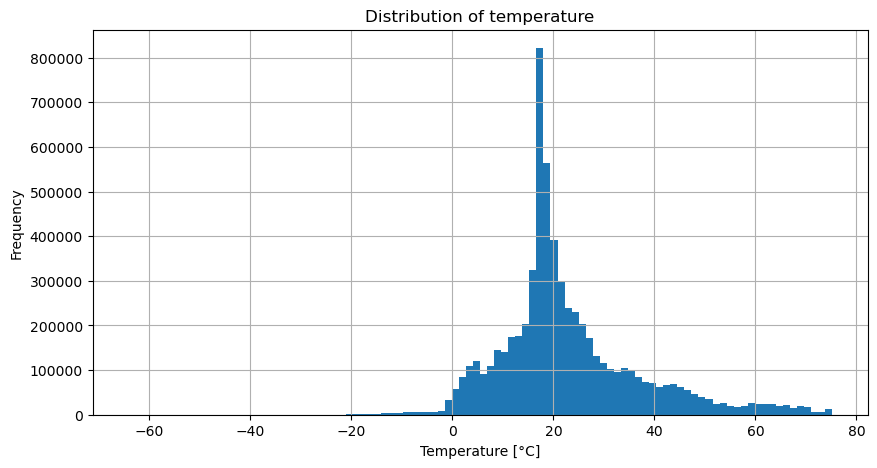

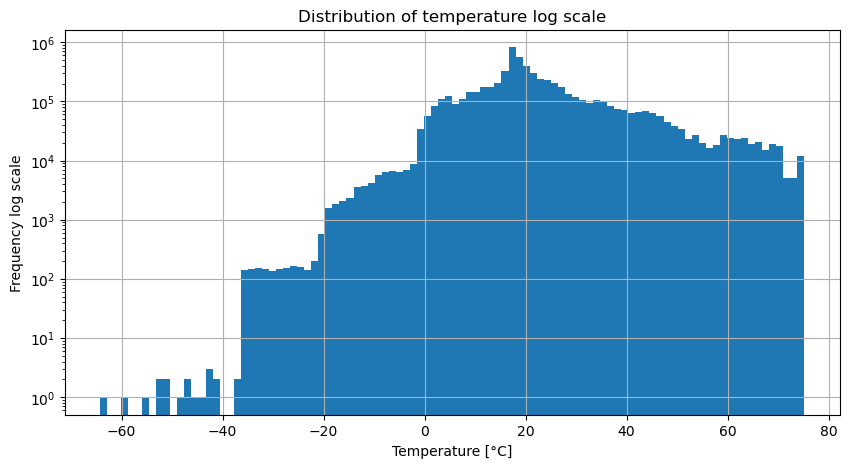

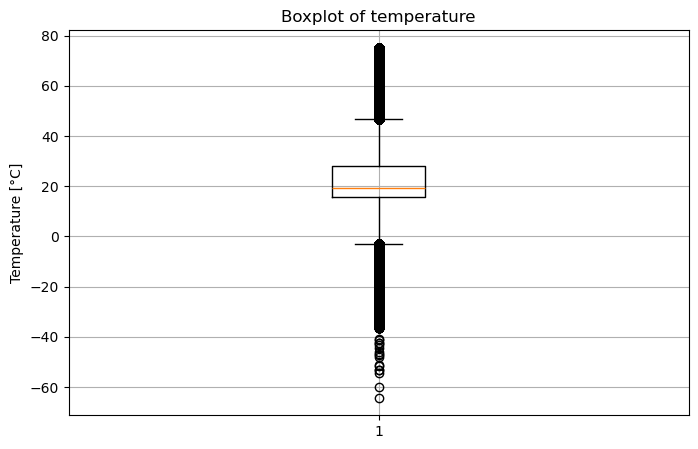

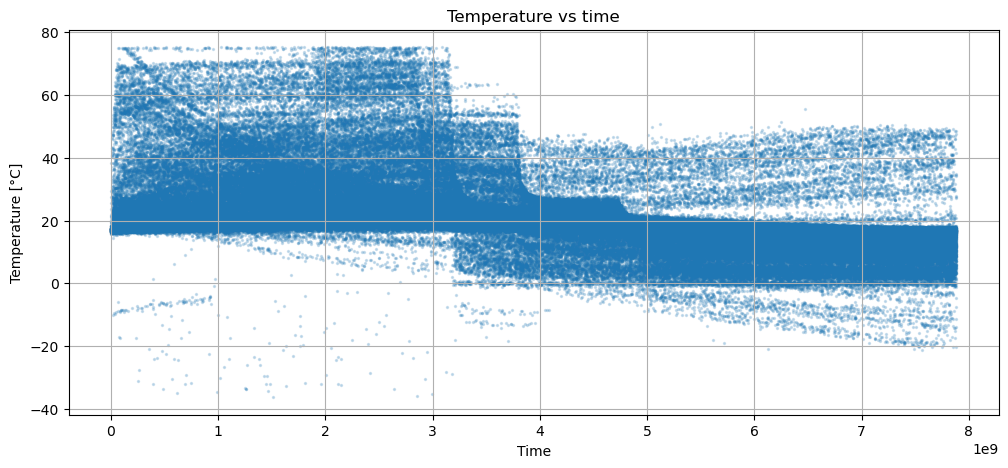

In [15]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

### 4.2 Division en 3 subsets selon le profil de puissance

In [29]:
# Assign repetition number
train_full['rep'] = train_full.groupby(['sensor', 'time']).cumcount()
train_full['time_years'] = train_full['time'] / (365.25 * 24 * 3600)
print('Reps:', train_full['rep'].value_counts().sort_index().to_dict())

Reps: {0: 2190126, 1: 2172023, 2: 2020183}


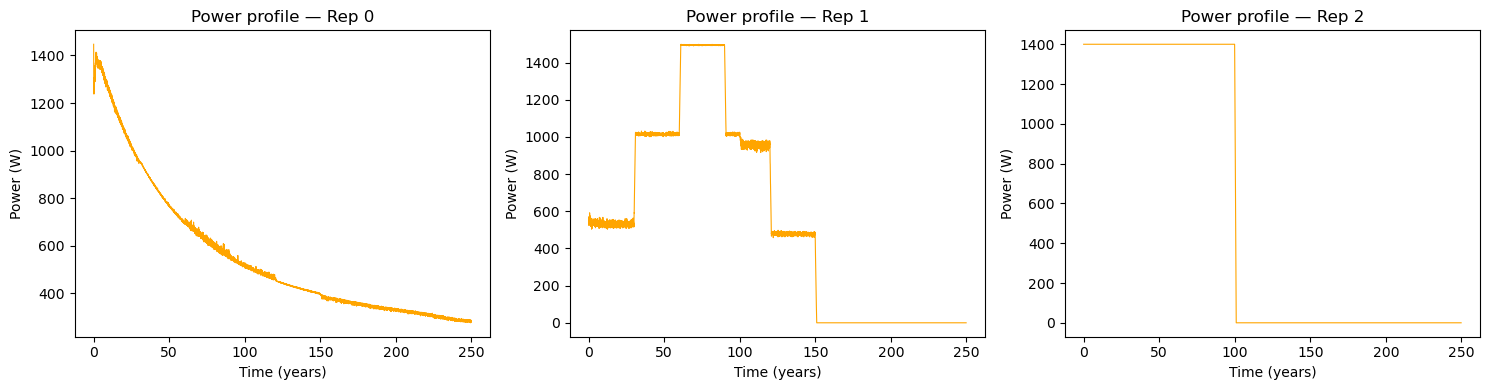

In [30]:
train_full['time_years'] = train_full['time'] / (365.25 * 24 * 3600)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for rep in [0, 1, 2]:
    d = train_full[train_full['rep']==rep].groupby('time_years')['power'].mean()
    axes[rep].plot(d.index, d.values, color='orange', linewidth=0.8)
    axes[rep].set_title(f'Power profile — Rep {rep}')
    axes[rep].set_xlabel('Time (years)')
    axes[rep].set_ylabel('Power (W)')

plt.tight_layout()
plt.show()

In [32]:
# Vérifier quel rank correspond à la décroissance radioactive
train_full['rep'] = train_full.groupby(['sensor', 'time'])['power'].rank(method='first').astype(int) - 1

# Regarder le profil de puissance de chaque rep sur le sensor N102
for rep in [0, 1, 2]:
    sub = train_full[(train_full['sensor'] == 'N102') & (train_full['rep'] == rep)].sort_values('time')
    print(f'Rep {rep}: power at t=0 = {sub["power"].iloc[0]:.1f}W | power at t=end = {sub["power"].iloc[-1]:.1f}W')

# Comparer avec le test
print(f'\nTest: power at first timestep = {test["power"].iloc[0]:.2f}W')
print(f'Test: power at last  timestep = {test["power"].iloc[-1]:.2f}W')

Rep 0: power at t=0 = 500.0W | power at t=end = 0.0W
Rep 1: power at t=0 = 1400.0W | power at t=end = 299.3W
Rep 2: power at t=0 = 1488.0W | power at t=end = 299.4W

Test: power at first timestep = 1487.29W
Test: power at last  timestep = 0.00W


In [37]:
# Identifier les reps par rank de power à chaque (sensor, time)
train['rep'] = train.groupby(['sensor', 'time'])['power'].rank(method='first').astype(int) - 1

# Diviser en 3 datasets
train_rep0 = train[train['rep'] == 0].drop(columns='rep').reset_index(drop=True)
train_rep1 = train[train['rep'] == 1].drop(columns='rep').reset_index(drop=True)
train_rep2 = train[train['rep'] == 2].drop(columns='rep').reset_index(drop=True)

print(f'Rep 0 (500W -> 0W)    : {len(train_rep0):,} rows, {train_rep0.sensor.nunique()} sensors')
print(f'Rep 1 (1400W -> 299W) : {len(train_rep1):,} rows, {train_rep1.sensor.nunique()} sensors')
print(f'Rep 2 (1488W -> 299W) : {len(train_rep2):,} rows, {train_rep2.sensor.nunique()} sensors')

# Sauvegarder si besoin
# train_rep0.to_parquet('data/train_rep0.parquet', index=False)
# train_rep1.to_parquet('data/train_rep1.parquet', index=False)
# train_rep2.to_parquet('data/train_rep2.parquet', index=False)

Rep 0 (500W -> 0W)    : 2,208,976 rows, 242 sensors
Rep 1 (1400W -> 299W) : 2,208,976 rows, 242 sensors
Rep 2 (1488W -> 299W) : 2,208,976 rows, 242 sensors


## sanity check

In [39]:
# Sanity check — vérifier que les 3 datasets sont cohérents

# 1. Taille totale
total = len(train_rep0) + len(train_rep1) + len(train_rep2)
assert total == len(train), f'Taille totale incorrecte: {total} != {len(train)}'
print(f'Total rows OK: {total:,} == {len(train):,}')

# 2. Chaque rep a exactement 1 ligne par (sensor, time)
for rep, df in [(0, train_rep0), (1, train_rep1), (2, train_rep2)]:
    counts = df.groupby(['sensor', 'time']).size()
    assert (counts == 1).all(), f'Rep {rep}: certains (sensor,time) ont plus dune ligne'
    print(f'Rep {rep}: chaque (sensor, time) a exactement 1 ligne OK')

# 3. Les 3 reps couvrent exactement les memes (sensor, time)
pairs_r0 = set(zip(train_rep0['sensor'], train_rep0['time']))
pairs_r1 = set(zip(train_rep1['sensor'], train_rep1['time']))
pairs_r2 = set(zip(train_rep2['sensor'], train_rep2['time']))
assert pairs_r0 == pairs_r1 == pairs_r2, 'Les 3 reps ne couvrent pas les memes (sensor, time)'
print('Memes (sensor, time) dans les 3 reps OK')
# 4. Même sensors dans les 3 reps
s0 = set(train_rep0['sensor'].unique())
s1 = set(train_rep1['sensor'].unique())
s2 = set(train_rep2['sensor'].unique())
assert s0 == s1 == s2, 'Les 3 reps nont pas les memes sensors'
print(f'Same sensors OK: {len(s0)} sensors dans chaque rep')

print('\nAll checks passed.')

Total rows OK: 6,626,928 == 6,626,928
Rep 0: chaque (sensor, time) a exactement 1 ligne OK
Rep 1: chaque (sensor, time) a exactement 1 ligne OK
Rep 2: chaque (sensor, time) a exactement 1 ligne OK
Memes (sensor, time) dans les 3 reps OK
Same sensors OK: 242 sensors dans chaque rep

All checks passed.


## data exploration: test set

=== SHAPE ===
Test : (2190480, 3) -> ['sensor', 'time', 'power']
Sensors in test : 80

=== SAMPLE ===


,sensor,time,power
0,N104,864000.0,1487.288818
1,N104,1728000.0,1486.612915
2,N104,2592000.0,1485.936890
3,N104,3456000.0,1485.260986
4,N104,4320000.0,1484.585083



=== TIME ===
Timesteps : 9127
Time range: 864000 -> 7884000000 s (0.0 -> 249.8 years)

=== POWER ===
count    2.190480e+06
mean     5.548834e+02
std      5.258164e+02
min      0.000000e+00
25%      0.000000e+00
50%      4.444925e+02
75%      1.000000e+03
max      1.500000e+03
Name: power, dtype: float64

=== SENSOR POSITIONS ===
coor_x range: 0.00 -> 50.00 m
coor_y range: 0.00 -> 3.50 m
Buffer sensors (x<1.4) : 15
OPA    sensors (x>=1.4): 65

=== POWER PROFILE PER SENSOR ===
           p_start  p_end      p_mean  p_min
count    80.000000   80.0   80.000000   80.0
mean   1487.288940    0.0  554.883362    0.0
std       0.000000    0.0    0.000000    0.0
min    1487.288818    0.0  554.883362    0.0
25%    1487.288818    0.0  554.883362    0.0
50%    1487.288818    0.0  554.883362    0.0
75%    1487.288818    0.0  554.883362    0.0
max    1487.288818    0.0  554.883362    0.0


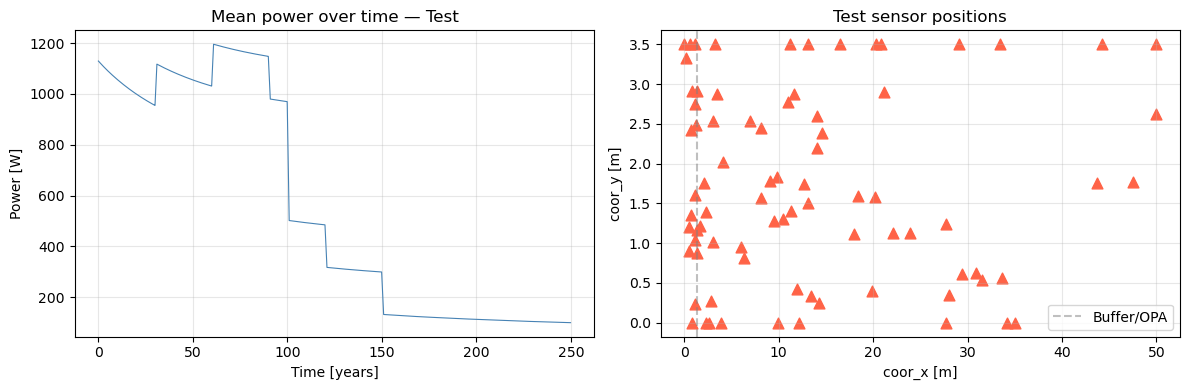

In [42]:
# ── Data exploration : Test set ───────────────────────────────────────────

print('=== SHAPE ===')
print(f'Test : {test.shape} -> {test.columns.tolist()}')
print(f'Sensors in test : {test["sensor"].nunique()}')

print('\n=== SAMPLE ===')
display(test.head(5))

print('\n=== TIME ===')
print(f'Timesteps : {test["time"].nunique()}')
print(f'Time range: {test["time"].min():.0f} -> {test["time"].max():.0f} s '
      f'({test["time"].min()/(365.25*24*3600):.1f} -> {test["time"].max()/(365.25*24*3600):.1f} years)')

print('\n=== POWER ===')
print(test['power'].describe())

print('\n=== SENSOR POSITIONS ===')
test_pos = test.merge(sensors, on='sensor', how='left')
print(f'coor_x range: {test_pos["coor_x"].min():.2f} -> {test_pos["coor_x"].max():.2f} m')
print(f'coor_y range: {test_pos["coor_y"].min():.2f} -> {test_pos["coor_y"].max():.2f} m')
print(f'Buffer sensors (x<1.4) : {(test_pos.groupby("sensor")["coor_x"].first() < 1.4).sum()}')
print(f'OPA    sensors (x>=1.4): {(test_pos.groupby("sensor")["coor_x"].first() >= 1.4).sum()}')

print('\n=== POWER PROFILE PER SENSOR ===')
test_profiles = (
    test.groupby('sensor')['power']
    .agg(p_start='first', p_end='last', p_mean='mean', p_min='min')
    .reset_index()
)
print(test_profiles.describe())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Power over time
temp_power = test.groupby('time')['power'].mean()
axes[0].plot(temp_power.index / (365.25*24*3600), temp_power.values,
             color='steelblue', linewidth=0.8)
axes[0].set_title('Mean power over time — Test')
axes[0].set_xlabel('Time [years]'); axes[0].set_ylabel('Power [W]')
axes[0].grid(True, alpha=0.3)

# Sensor positions
axes[1].scatter(test_pos.groupby('sensor')['coor_x'].first(),
                test_pos.groupby('sensor')['coor_y'].first(),
                c='tomato', s=60, marker='^')
axes[1].axvline(1.4, color='gray', linestyle='--', alpha=0.5, label='Buffer/OPA')
axes[1].set_title('Test sensor positions')
axes[1].set_xlabel('coor_x [m]'); axes[1].set_ylabel('coor_y [m]')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### observation: this graph looks like a combination of the 3 different curves of power over time, let's see if it's really the case:

In [43]:
print(f'Test  : {len(test):,} lignes, {test["sensor"].nunique()} sensors, {test["time"].nunique()} timesteps')
print(f'Train : {len(train):,} lignes, {train["sensor"].nunique()} sensors, {train["time"].nunique()} timesteps')
print(f'Ratio : {len(train)/len(test):.1f}x plus de lignes dans le train')

Test  : 2,190,480 lignes, 80 sensors, 9127 timesteps
Train : 6,626,928 lignes, 242 sensors, 9128 timesteps
Ratio : 3.0x plus de lignes dans le train


## Does test parquet also have 3 reps?

In [44]:
# Combien de lignes par (sensor, time) dans le test ?
counts = test.groupby(['sensor', 'time']).size()
print('Lignes par (sensor, time) :')
print(counts.value_counts())

Lignes par (sensor, time) :
3    730160
Name: count, dtype: int64


###YESSS! 80 sensors × 3 reps × 9127 timesteps = 2,190,480 lignes, as seen 2 cells before

In [45]:
# Profil de puissance par rep dans le test
test['rep'] = test.groupby(['sensor', 'time'])['power'].rank(method='first').astype(int) - 1

for rep in [0, 1, 2]:
    sub = test[test['rep'] == rep]
    p0   = sub[sub['time'] == sub['time'].min()]['power'].mean()
    pend = sub[sub['time'] == sub['time'].max()]['power'].mean()
    print(f'Test Rep {rep}: power at t=start = {p0:.1f}W | power at t=end = {pend:.1f}W')

Test Rep 0: power at t=start = 500.0W | power at t=end = 0.0W
Test Rep 1: power at t=start = 1400.0W | power at t=end = 0.0W
Test Rep 2: power at t=start = 1487.3W | power at t=end = 299.3W
